In [34]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_curve, auc, classification_report

In [35]:
x_train_balanced = pd.read_csv("X_train_balanced.csv").values
x_val = pd.read_csv("X_val.csv").values
x_test = pd.read_csv("X_test.csv").values

y_train_balanced = pd.read_csv("y_train_balanced.csv").values.ravel()
y_val = pd.read_csv("y_val.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()

In [36]:
df_y = pd.DataFrame(data = y_train_balanced)
df_y

,0
0,0
1,0
2,0
3,1
4,0
...,...
299179,1
299180,1
299181,1
299182,1


In [37]:
has_diabetes = ["0", "1"]
enc = OrdinalEncoder(categories=[has_diabetes])
df_y[0] = enc.fit_transform(df_y[[0]])
df_y

,0
0,0.0
1,0.0
2,0.0
3,1.0
4,0.0
...,...
299179,1.0
299180,1.0
299181,1.0
299182,1.0


In [38]:
df_x = pd.DataFrame(data = x_train_balanced)
df_x

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,0.896681,-1.110562,0.159201,-0.677784,-0.990786,-0.263653,-0.434203,0.668982,0.819065,0.530123,...,0.219181,-0.327882,-0.765354,-0.455382,-0.572176,-0.598325,-0.950983,0.849852,1.076524,1.062246
1,-1.188693,-1.110562,-6.447992,0.437708,-0.990786,-0.263653,-0.434203,0.668982,0.819065,0.530123,...,0.219181,-0.327882,0.156684,1.397341,-0.572176,-0.598325,1.142868,-0.565307,-0.949595,1.062246
2,0.896681,-1.110562,0.159201,0.437708,1.100773,-0.263653,-0.434203,0.668982,0.819065,0.530123,...,0.219181,-0.327882,1.078722,-0.455382,-0.372888,-0.598325,-0.950983,-0.211517,-0.949595,-1.271011
3,0.896681,0.973745,0.159201,-0.538347,1.100773,4.468666,2.631026,0.668982,0.819065,0.530123,...,0.219181,-0.327882,0.156684,-0.455382,-0.572176,1.819520,1.142868,1.203642,1.076524,-1.271011
4,0.896681,0.973745,0.159201,0.716581,1.100773,-0.263653,-0.434203,-1.652785,0.819065,0.530123,...,0.219181,-0.327882,1.078722,1.273826,0.025687,1.819520,-0.950983,0.849852,-2.975714,-2.204314
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299179,-0.903323,0.973745,0.159201,2.548335,-0.990786,-0.263653,-0.434203,-1.335066,-1.338952,0.170075,...,0.219181,-0.327882,2.000760,2.666294,2.262952,1.819520,0.856337,-1.529849,-0.213798,-1.801521
299180,-0.945030,-0.867024,0.159201,-0.275767,-0.990786,-0.263653,-0.434203,0.668982,0.819065,0.530123,...,0.219181,-0.327882,0.156684,-0.208352,-0.384531,-0.598325,-0.950983,-0.170179,1.076524,0.650120
299181,0.896681,-1.110562,0.159201,-0.716712,-0.990786,3.147467,0.421568,0.668982,0.819065,0.530123,...,0.219181,-0.327882,-1.429972,-0.455382,-0.572176,-0.598325,-0.950983,1.557432,1.076524,0.465312
299182,0.224875,0.302283,0.159201,-0.398911,-0.316988,-0.263653,-0.434203,-0.904825,0.819065,0.530123,...,0.219181,-0.327882,0.781686,-0.455382,1.420700,1.819520,-0.950983,1.557432,0.423807,-0.654027


In [39]:
scaler = MinMaxScaler()
df_x_scaled = pd.DataFrame(scaler.fit_transform(df_x), columns=df_x.columns)

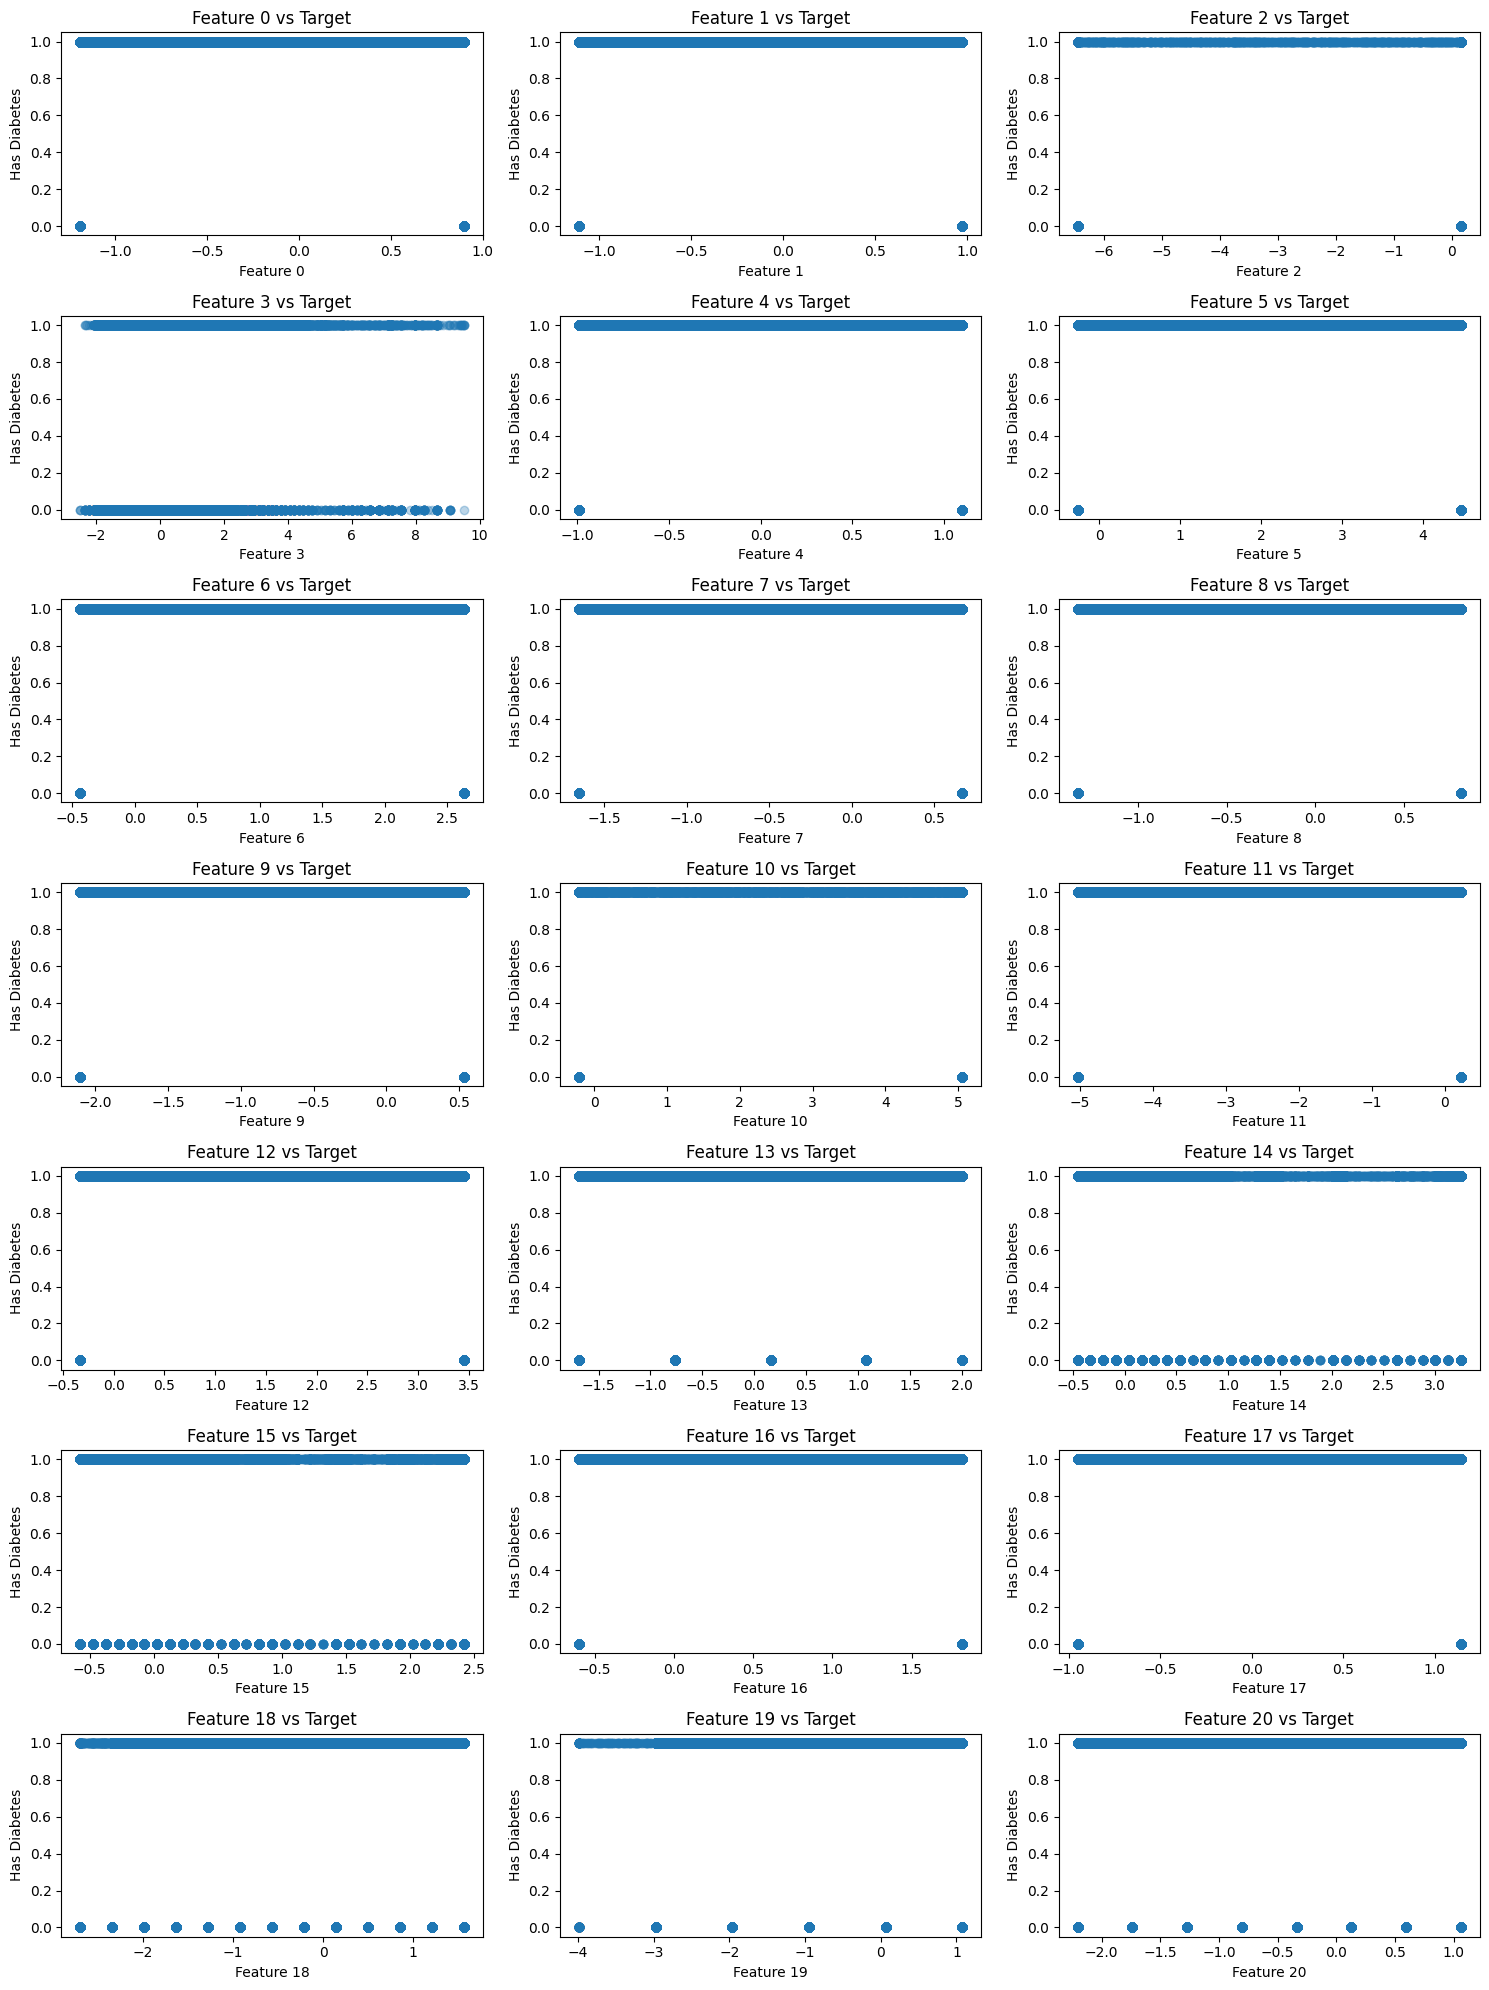

In [40]:
n_features = df_x.shape[1]  
fig, axes = plt.subplots(nrows=7, ncols=3, figsize=(15, 20)) 
axes = axes.flatten()  

for i in range(n_features):
    axes[i].scatter(df_x[i], df_y[0], alpha=0.3)
    axes[i].set_xlabel(f"Feature {i}")
    axes[i].set_ylabel("Has Diabetes")
    axes[i].set_title(f"Feature {i} vs Target")


for j in range(n_features, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

<Axes: xlabel='0', ylabel='count'>

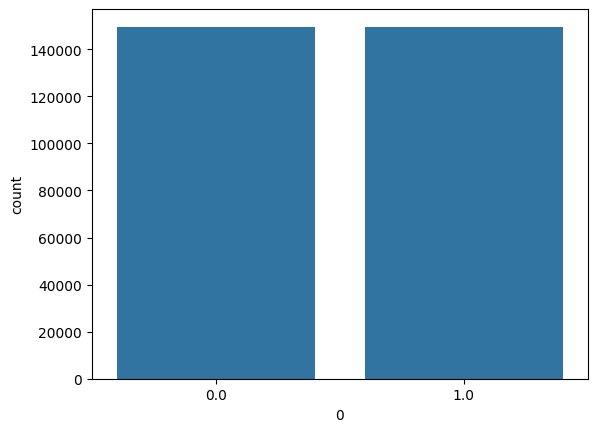

In [41]:
sns.countplot(x=df_y[0])

In [42]:
column_names = [
    "HighBP","HighChol","CholCheck","BMI","Smoker","Stroke",
    "HeartDiseaseorAttack","PhysActivity","Fruits","Veggies",
    "HvyAlcoholConsump","AnyHealthcare","NoDocbcCost","GenHlth",
    "MentHlth","PhysHlth","DiffWalk","Sex","Age","Education","Income"
]

df_x_scaled.columns = column_names

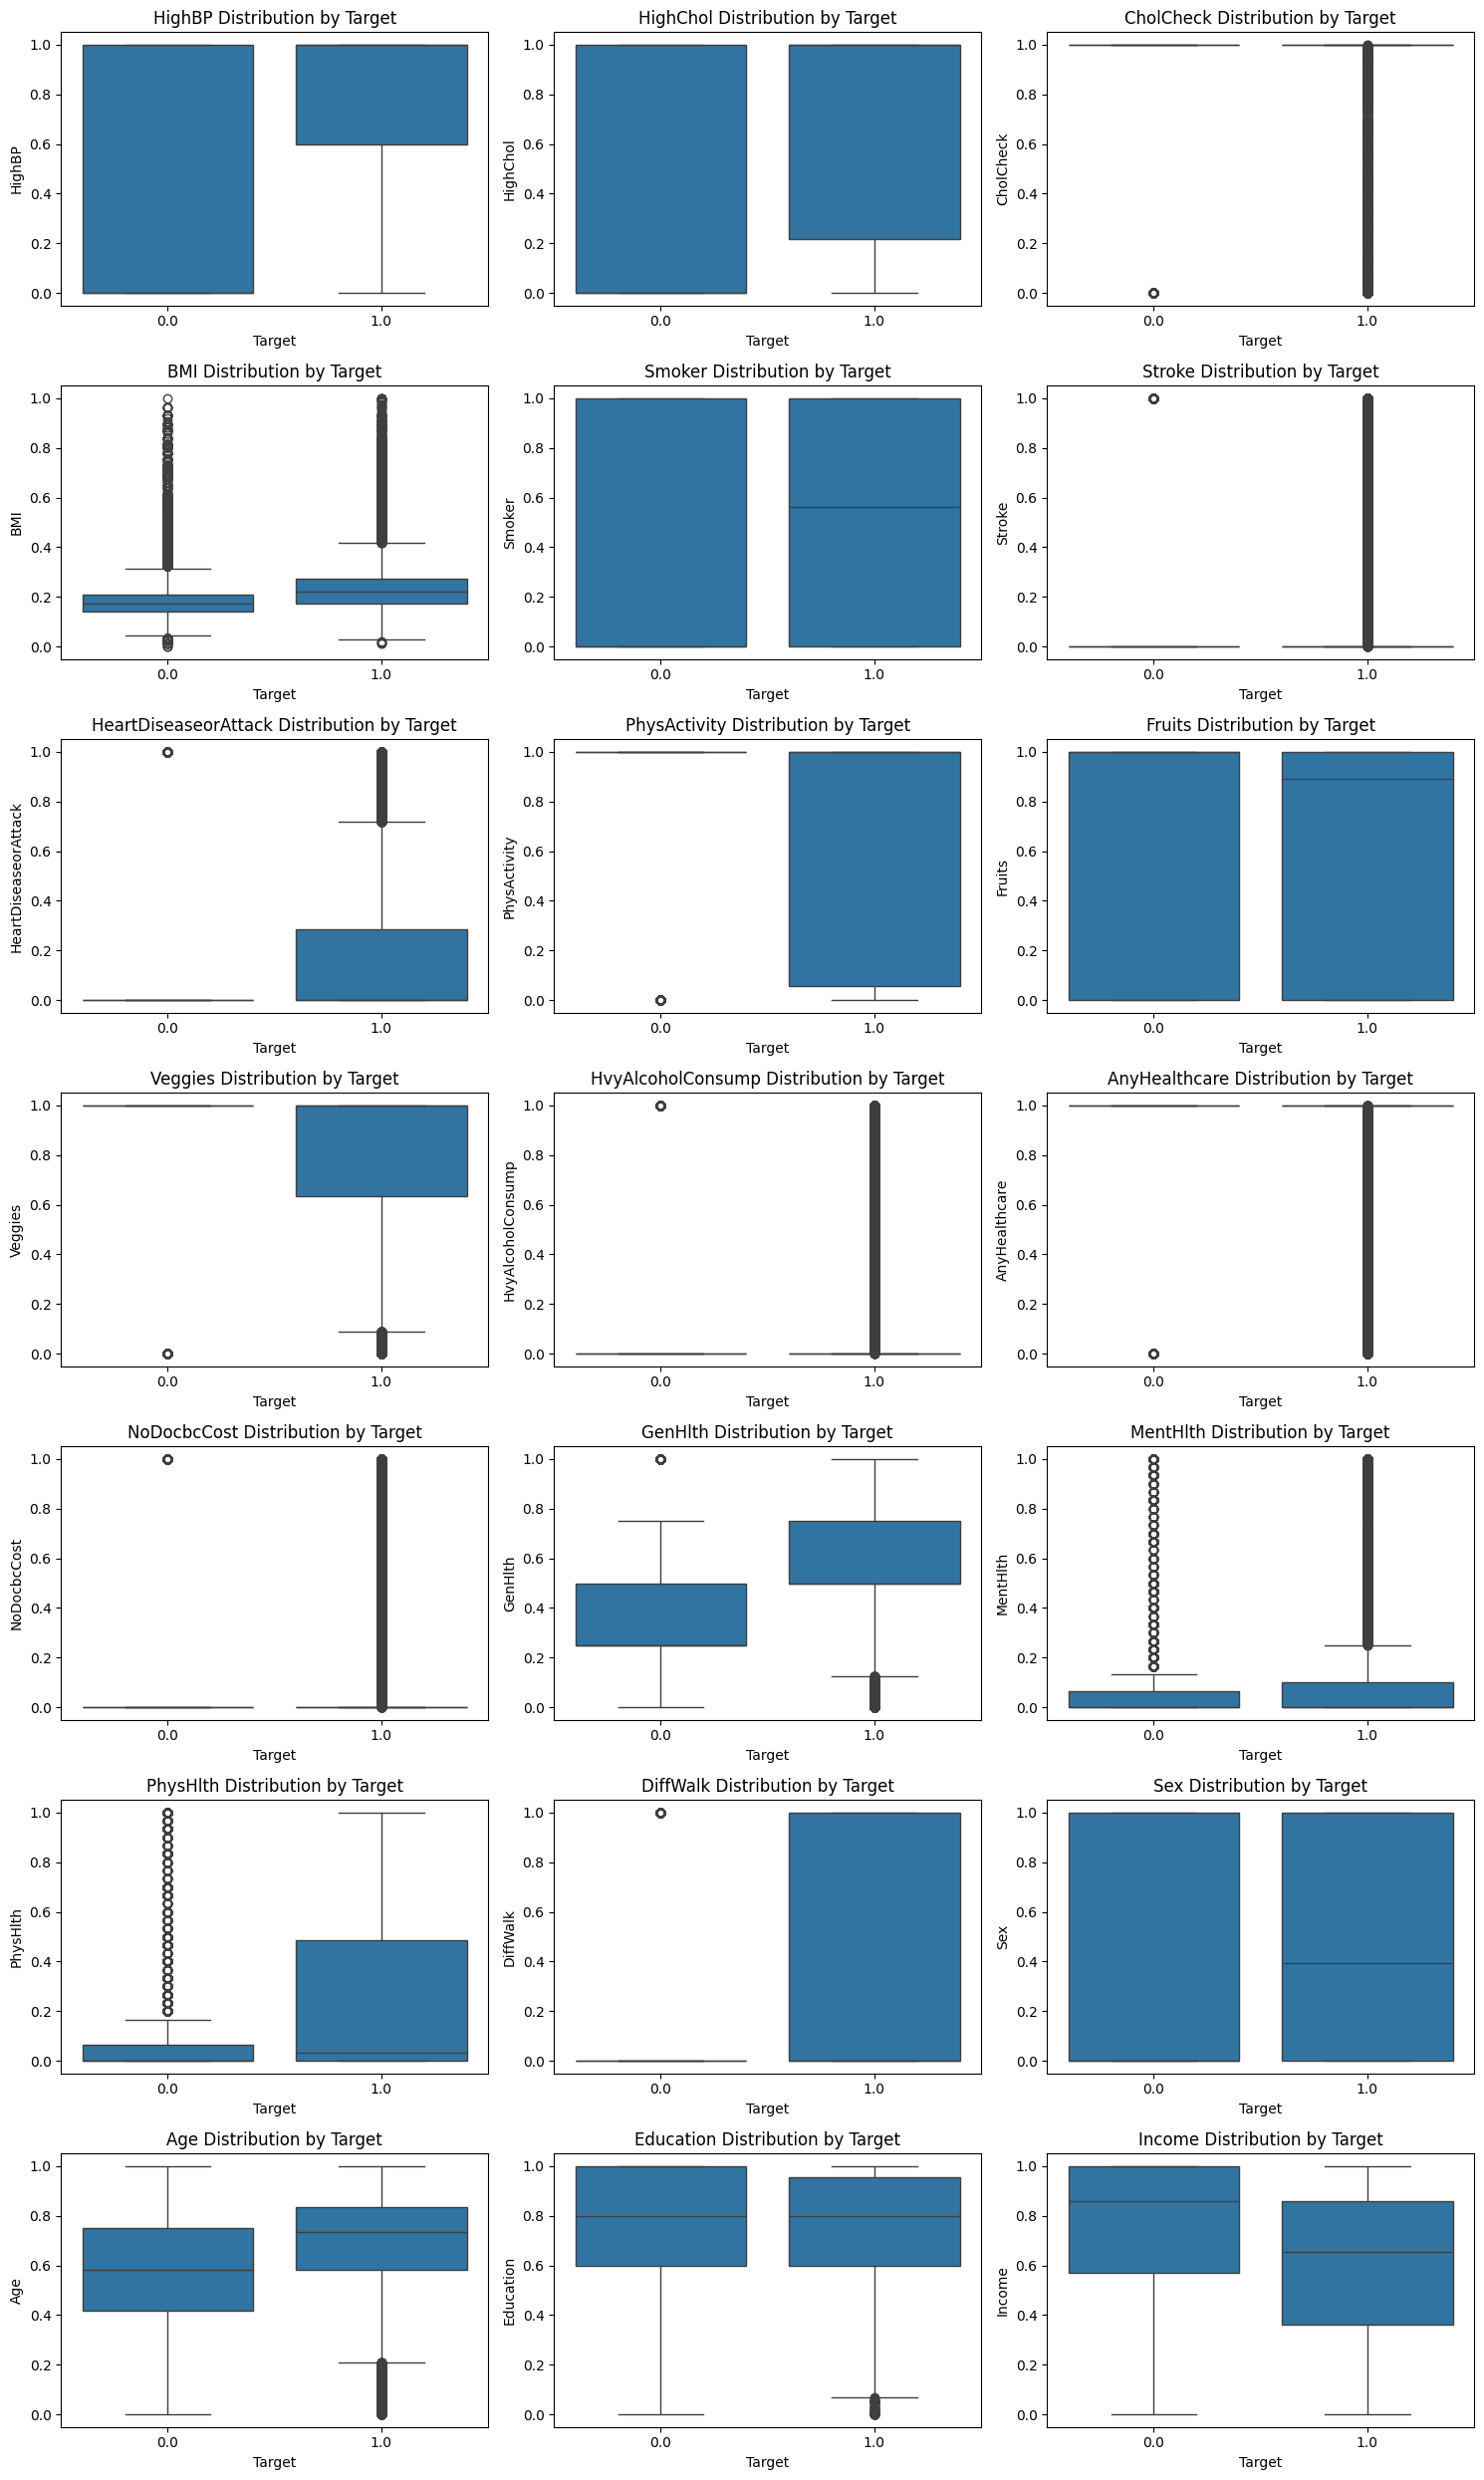

<Figure size 640x480 with 0 Axes>

In [43]:

temp_df = df_x_scaled.copy()
temp_df['Target'] = df_y[0]

n_features = len(column_names)

fig, axes = plt.subplots(nrows=7, ncols=3, figsize=(15, 25))
axes = axes.flatten()

for i, col in enumerate(column_names):
    sns.boxplot(x='Target', y=col, data=temp_df, ax=axes[i])
    axes[i].set_title(f"{col} Distribution by Target")

plt.tight_layout()
plt.show()

plt.tight_layout()

In [44]:
# features chosen: HighBP, HighChol, BMI, HeartDiseaseorAttack, PhysHlth, GenHlth, DiffWalk, Age
features_to_use = [0, 1, 3, 6, 15, 13, 16, 18]
X_train_final = df_x_scaled.iloc[:, features_to_use].values
Y_train_final = df_y[0].values

In [45]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

param_dist = {
    'C': loguniform(1e-3, 1e3),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'max_iter': [200, 500, 1000]
}

random_search = RandomizedSearchCV(
    LogisticRegression(),
    param_dist,
    n_iter=30,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_final, Y_train_final)
print("Best params:", random_search.best_params_)
logreg = random_search.best_estimator_
from sklearn.model_selection import cross_val_score
scores = cross_val_score(logreg, X_train_final, Y_train_final, cv=10, scoring='roc_auc')
print(scores.mean(), scores.std())

Best params: {'C': 339.8172415010595, 'max_iter': 500, 'penalty': 'l1', 'solver': 'liblinear'}
0.8289532521889157 0.00394699297706082


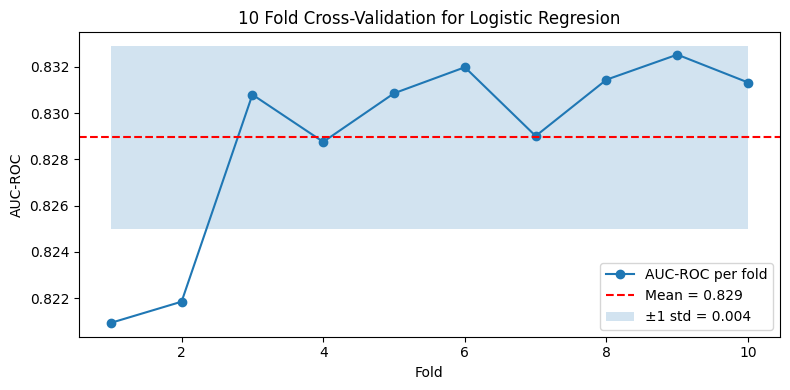

In [46]:
import matplotlib.pyplot as plt
import numpy as np

folds = range(1, 11)
plt.figure(figsize=(8, 4))
plt.plot(folds, scores, marker='o', label='AUC-ROC per fold')
plt.axhline(scores.mean(), color='r', linestyle='--', label=f'Mean = {scores.mean():.3f}')
plt.fill_between(folds, scores.mean() - scores.std(), scores.mean() + scores.std(), alpha=0.2, label=f'±1 std = {scores.std():.3f}')
plt.xlabel('Fold')
plt.ylabel('AUC-ROC')
plt.title('10 Fold Cross-Validation for Logistic Regresion')
plt.legend()
plt.tight_layout()
plt.savefig('cv_scores.png', dpi=300)

In [47]:
x_val_scaled = scaler.transform(x_val)
x_val_selected = x_val_scaled[:, features_to_use]
y_probs = logreg.predict_proba(x_val_selected)[:, 1]
y_predicted = (y_probs >= 0.3).astype(int)
print(f"Accuracy: {accuracy_score(y_val, y_predicted):.4f}")

Accuracy: 0.5932


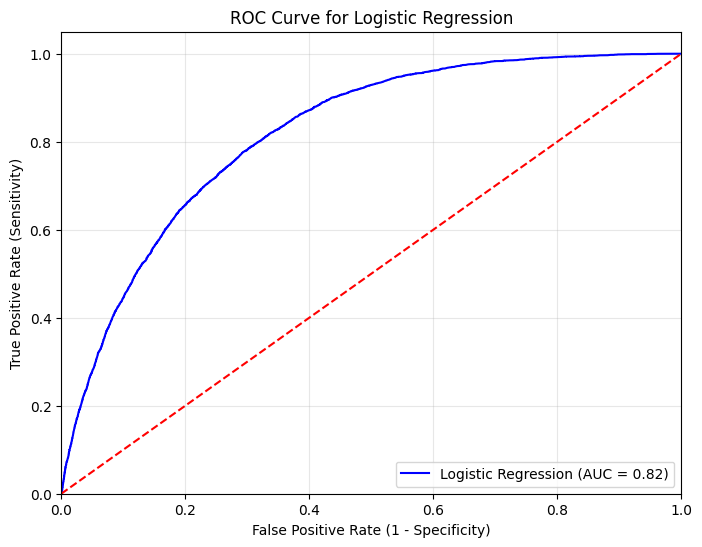

In [48]:
fpr, tpr, thresholds = roc_curve(y_val, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve for Logistic Regression')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score
y_test = y_test[:len(y_predicted)]
accuracy = accuracy_score(y_test, y_predicted)
precision = precision_score(y_test, y_predicted, zero_division=0)
recall = recall_score(y_test, y_predicted, zero_division=0)
f1 = f1_score(y_test, y_predicted, zero_division=0)
auc_score = roc_auc_score(y_test, y_probs)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))
print("ROC AUC  :", round(auc_score, 4))

Accuracy : 0.4848
Precision: 0.1432
Recall   : 0.5277
F1-score : 0.2253
ROC AUC  : 0.5046


Text(0.5, 1.0, 'Logistic Regression Metric Results')

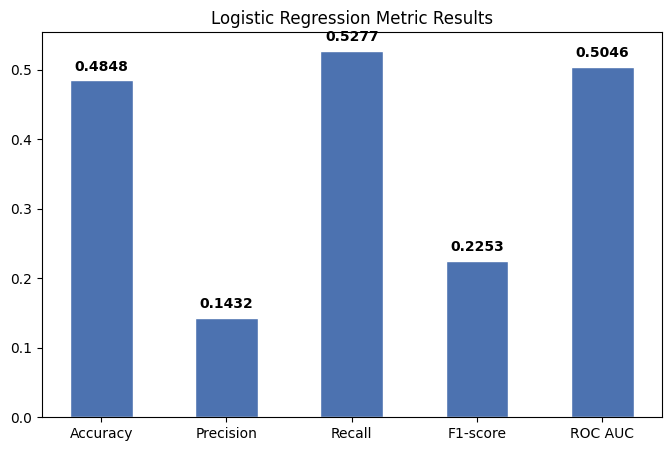

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC AUC"],
    "Score":  [round(accuracy, 4),    round(precision, 4),      round(recall, 4),   round(f1, 4),     round(auc_score, 4)]
}

df = pd.DataFrame(data)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(df["Metric"], df["Score"], color=["#4C72B0"], edgecolor="white", width=0.5)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.4f}",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_title("Logistic Regression Metric Results")
